In [97]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Реализация Линейной регрессии

In [ ]:
class LinearRegression:   
    def __init__(self):
        self.coef_ = None
        self.intercept_ = None
        self.r_squared = None
        self.mse = None
        
    def add_intercept(self, X):
        return np.column_stack([np.ones(X.shape[0]), X])
    
    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        
        X_design = self.add_intercept(X)
        
        XT_X = X_design.T @ X_design
        
        try:
            theta = np.linalg.inv(XT_X) @ X_design.T @ y
        except np.linalg.LinAlgError:
            theta = np.linalg.pinv(XT_X) @ X_design.T @ y
        
        self.intercept_ = theta[0][0]
        self.coef_ = theta[1:].flatten()
        
        # Вычисляем метрики на тренировочных данных
        y_pred_train = self.predict(X)
        self.compute_metrics(y, y_pred_train)
        
        return self
    
    def predict(self, X):
        X = np.array(X)
        return self.intercept_ + X @ self.coef_
    
    def compute_metrics(self, y_true, y_pred):
        y_true = y_true.flatten()
        y_pred = y_pred.flatten()
        
        self.mse = np.mean((y_true - y_pred) ** 2)
        ss_res = np.sum((y_true - y_pred) ** 2)
        ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
        self.r_squared = 1 - (ss_res / ss_tot)

        print(f"Train MSE: {self.mse:.6f}")
        print(f"Train R2: {self.r_squared:.6f}")
        print()

    def score(self, X, y):
        y_pred = self.predict(X)
        y_true = np.array(y).flatten()
        
        res = np.sum((y_true - y_pred) ** 2)
        tot = np.sum((y_true - np.mean(y_true)) ** 2)
        return 1 - (res / tot)

# Предобработка данных

In [99]:
df = pd.read_csv('data/car_price.csv')
df.head()

,Unnamed: 0,car_name,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,0,Jeep Compass 2.0 Longitude Option BSIV,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,1,Renault Duster RXZ Turbo CVT,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,2,Toyota Camry 2.5 G,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,3,Honda Jazz VX CVT,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,4,Volkswagen Polo 1.2 MPI Highline,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


In [100]:
df.isna().sum() # Пропуски

Unnamed: 0             0
car_name               0
car_prices_in_rupee    0
kms_driven             0
fuel_type              0
transmission           0
ownership              0
manufacture            0
engine                 0
Seats                  0
dtype: int64

In [101]:
df.drop(['Unnamed: 0', 'car_name'], axis=1, inplace=True)
df.head()

,car_prices_in_rupee,kms_driven,fuel_type,transmission,ownership,manufacture,engine,Seats
0,10.03 Lakh,"86,226 kms",Diesel,Manual,1st Owner,2017,1956 cc,5 Seats
1,12.83 Lakh,"13,248 kms",Petrol,Automatic,1st Owner,2021,1330 cc,5 Seats
2,16.40 Lakh,"60,343 kms",Petrol,Automatic,1st Owner,2016,2494 cc,5 Seats
3,7.77 Lakh,"26,696 kms",Petrol,Automatic,1st Owner,2018,1199 cc,5 Seats
4,5.15 Lakh,"69,414 kms",Petrol,Manual,1st Owner,2016,1199 cc,5 Seats


In [102]:
df['car_prices_in_rupee'] = df['car_prices_in_rupee'].apply(
    lambda s: float(s.replace('Lakh', '').replace('Crore', '').replace(' ', '').replace(',', ''))
).astype(np.float32)

df['kms_driven'] = df['kms_driven'].apply(
    lambda s: float(s.replace(' kms', '').replace(' ', '').replace(',', ''))
).astype(np.float32)

df['ownership'] = df['ownership'].apply(lambda s: float(s[:1])).astype(np.float32)

df['Seats'] = df['Seats'].apply(lambda s: float(s[:1])).astype(np.float32)

df['engine'] = df['engine'].apply(lambda s: float(s[:-2])).astype(np.float32)

In [103]:
# Трансмиссия бывает только одного из 2 видов
df['is_transmission_Automatic'] = df['transmission'].apply(lambda s: 1 if s == 'Automatic' else 0).astype(bool)
df.drop(['transmission'], axis=1, inplace=True)

In [104]:
df = pd.get_dummies(df) # One-Hot для колонки fuel

In [105]:
df.dtypes # Все признаки теперь числовые

car_prices_in_rupee          float32
kms_driven                   float32
ownership                    float32
manufacture                    int64
engine                       float32
Seats                        float32
is_transmission_Automatic       bool
fuel_type_Cng                   bool
fuel_type_Diesel                bool
fuel_type_Electric              bool
fuel_type_Lpg                   bool
fuel_type_Petrol                bool
dtype: object

**Корреляция**

[]

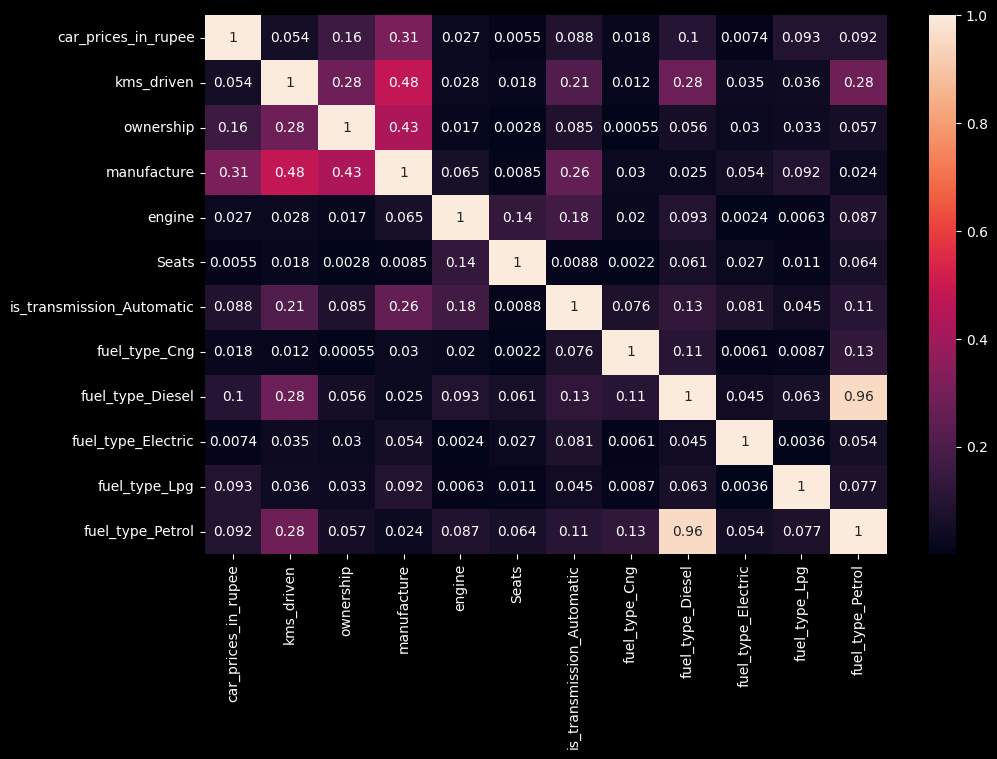

In [106]:
import seaborn as sns

plt.figure(figsize=(11, 7))
sns.heatmap(np.abs(df.corr()), annot=True)
plt.plot()

**Удаляем колонки с преступно низкой корреляцией**

In [107]:
target_column = 'car_prices_in_rupee'

In [108]:
for col in df.columns: 
    val = df[col].corr(df[target_column])
    if np.abs(val) < 0.01: 
        print(f'target - {col}: {val}')
        df.drop([col], axis=1, inplace=True)

target - Seats: -0.0055343846202856916
target - fuel_type_Electric: -0.007423963000249672


[]

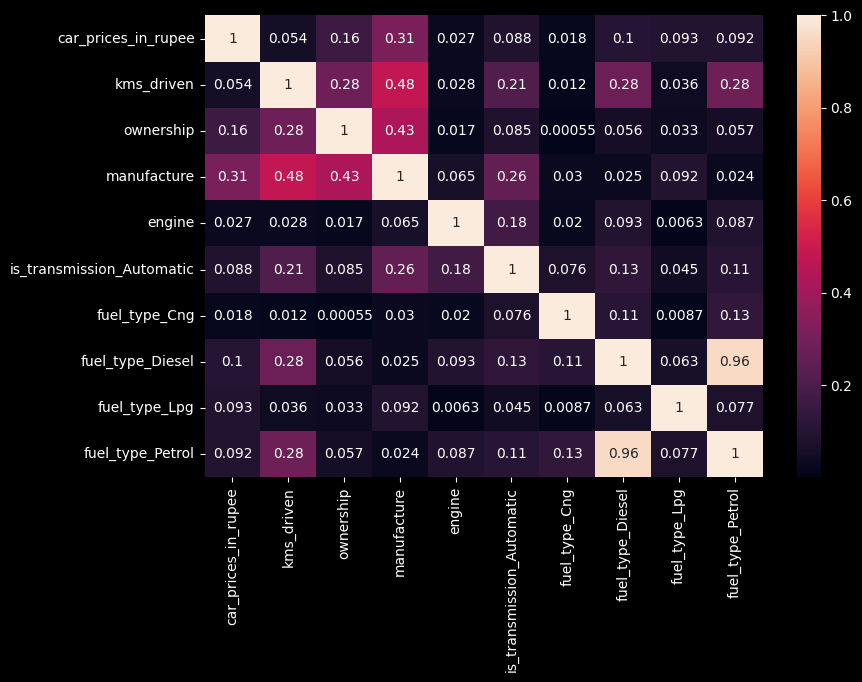

In [109]:
plt.figure(figsize=(9, 6))
sns.heatmap(np.abs(df.corr()), annot=True)
plt.plot()

**Скейлинг и разбиение данных**

In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


SEED = 42

X = df.drop(columns=[target_column])
y = np.log(df[target_column])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=SEED
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

# Применение Линейной регрессии

## Моя реализация

In [111]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred_test = model.predict(X_test_scaled)

mse_test = np.mean((y_test - y_pred_test) ** 2)
r2_test = model.score(X_test_scaled, y_test)
print(f"Test MSE: {mse_test:.6f}")
print(f"Test R2: {r2_test:.6f}")

Train MSE: 2.671572
Train R2: 0.086307

Test MSE: 2.089931
Test R2: 0.103195


## Реализация из sklearn

In [112]:
from sklearn.linear_model import LinearRegression as SkLinearRegression
from sklearn.metrics import mean_squared_error, r2_score


sk_model = SkLinearRegression()
sk_model.fit(X_train_scaled, y_train)

# Метрики на тренировочных данных
y_pred_train = sk_model.predict(X_train_scaled)
mse_train = mean_squared_error(y_train, y_pred_train)
r2_train = r2_score(y_train, y_pred_train)

print(f"Train MSE: {mse_train:.6f}")
print(f"Train R2: {r2_train:.6f}")
print()

# Метрики на тестовых данных
y_pred_test = sk_model.predict(X_test_scaled)
mse_test = mean_squared_error(y_test, y_pred_test)
r2_test = r2_score(y_test, y_pred_test)

print(f"Test MSE: {mse_test:.6f}")
print(f"Test R2: {r2_test:.6f}")

Train MSE: 2.671572
Train R2: 0.086307

Test MSE: 2.089931
Test R2: 0.103195


## Использование иных готовых моделей

In [113]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

In [114]:
models = {
    'Random Forest': RandomForestRegressor(n_estimators=50, max_depth=10, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=SEED),
}

results = {
    'Model': [],
    'Train MSE': [],
    'Test MSE': [],
    'Train R2': [],
    'Test R2': []
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)

    y_train_pred = model.predict(X_train_scaled)
    y_test_pred = model.predict(X_test_scaled)

    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    results['Model'].append(name)
    results['Train MSE'].append(train_mse)
    results['Test MSE'].append(test_mse)
    results['Train R2'].append(train_r2)
    results['Test R2'].append(test_r2)

    print(f"\n{name}:")
    print(f"  Train MSE: {train_mse:.6f}")
    print(f"  Test MSE:  {test_mse:.6f}")
    print(f"  Train R2:  {train_r2:.6f}")
    print(f"  Test R2:   {test_r2:.6f}")

results_df = pd.DataFrame(results)


Random Forest:
  Train MSE: 1.012348
  Test MSE:  1.856575
  Train R2:  0.653771
  Test R2:   0.203329

Gradient Boosting:
  Train MSE: 1.844079
  Test MSE:  1.735514
  Train R2:  0.369314
  Test R2:   0.255278


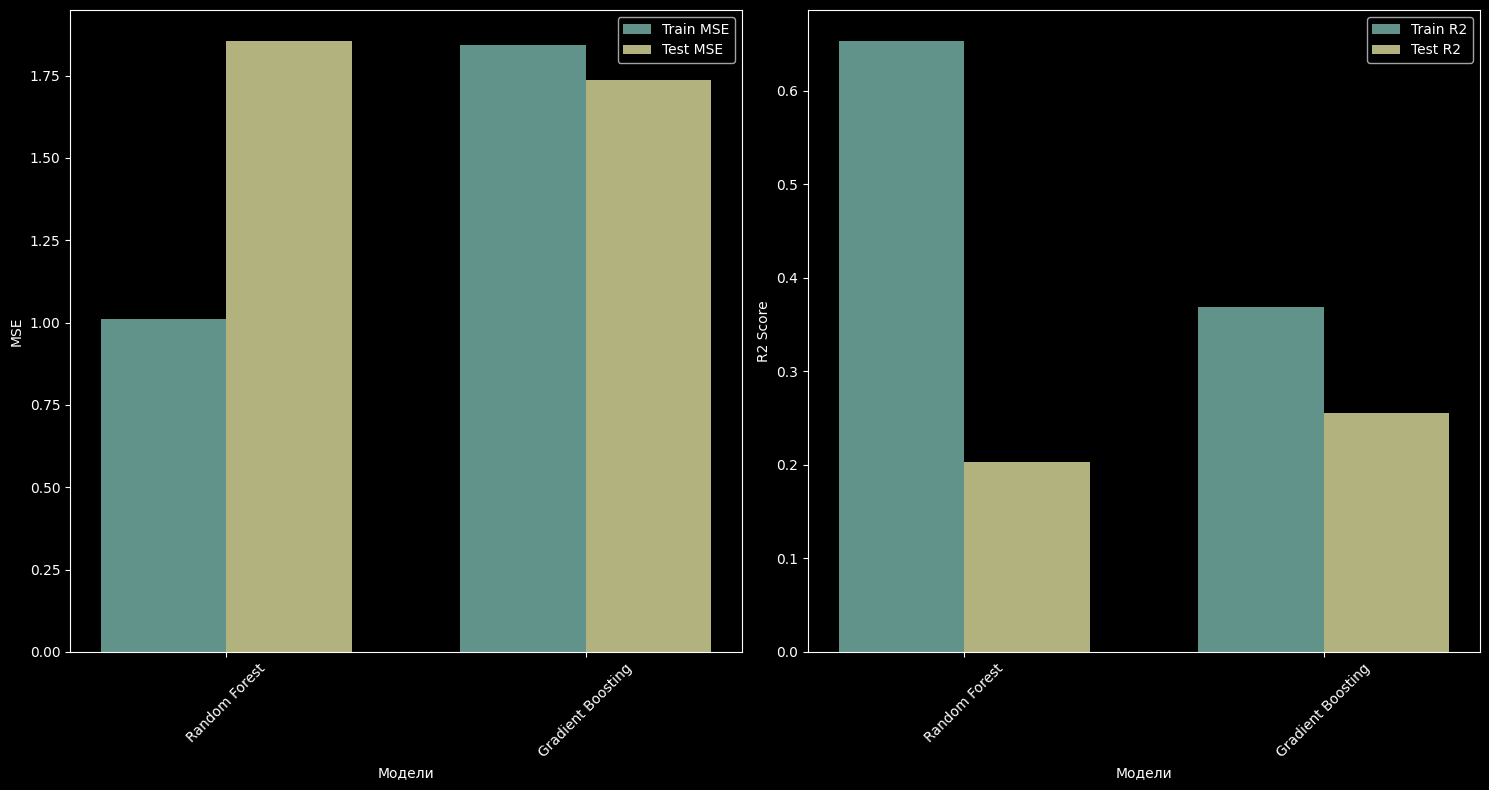

In [115]:
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)

x_pos = np.arange(len(results_df))
width = 0.35

plt.bar(x_pos - width/2, results_df['Train MSE'], width, label='Train MSE', alpha=0.7)
plt.bar(x_pos + width/2, results_df['Test MSE'], width, label='Test MSE', alpha=0.7)

plt.xlabel('Модели')
plt.ylabel('MSE')

plt.xticks(x_pos, results_df['Model'], rotation=45)
plt.legend()

plt.subplot(1, 2, 2)

plt.bar(x_pos - width/2, results_df['Train R2'], width, label='Train R2', alpha=0.7)
plt.bar(x_pos + width/2, results_df['Test R2'], width, label='Test R2', alpha=0.7)

plt.xlabel('Модели')
plt.ylabel('R2 Score')

plt.xticks(x_pos, results_df['Model'], rotation=45)
plt.legend()

plt.tight_layout()
plt.show()